# **Actividad Fundamental 7**
### ***Redes Neuronales Artificiales***
Integrantes

Levi Abdiel Tiburcio Sánchez - 2178165 - N5

Julio César Ramírez Martínez - 2094921 - N5

Andrés Fernando Montes Aguilar - 2097799 - N5

Manuel Sebastián Garza Garza - 2096889 - N5

Juan Ángel Salazar Yáñez - 2120777 - N5

In [4]:
#Carga de librerías
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [5]:
#Carga de datos
num=keras.datasets.mnist
(train_data, train_labels), (test_data, test_labels) = num.load_data()
print("Entrenamiento:", train_data.shape)
print("Prueba:", test_data.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Entrenamiento: (60000, 28, 28)
Prueba: (10000, 28, 28)


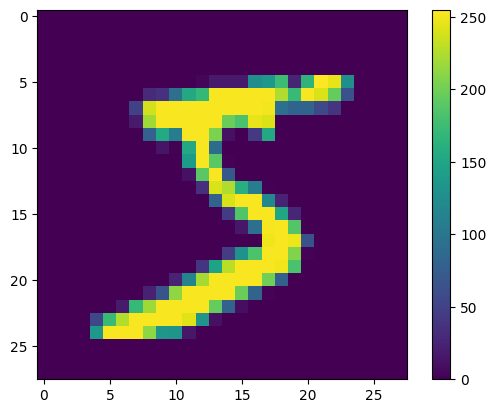

In [6]:
#Pre-procesamiento de datos
#Inspección de los datos
plt.figure()
plt.imshow(train_data[0])
plt.colorbar()
plt.grid(False)
plt.show()

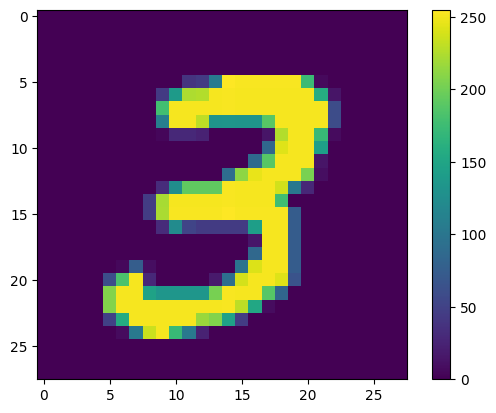

In [7]:
plt.figure()
plt.imshow(train_data[7])
plt.colorbar()
plt.grid(False)
plt.show()

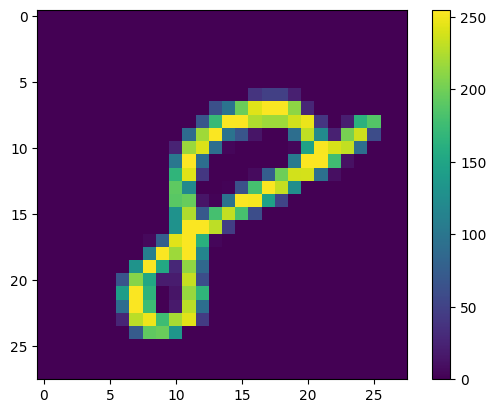

In [8]:
plt.figure()
plt.imshow(train_data[-1])
plt.colorbar()
plt.grid(False)
plt.show()

In [9]:
#Normalizamos los valores de los pixeles
train_data = train_data/255
test_data = test_data/255

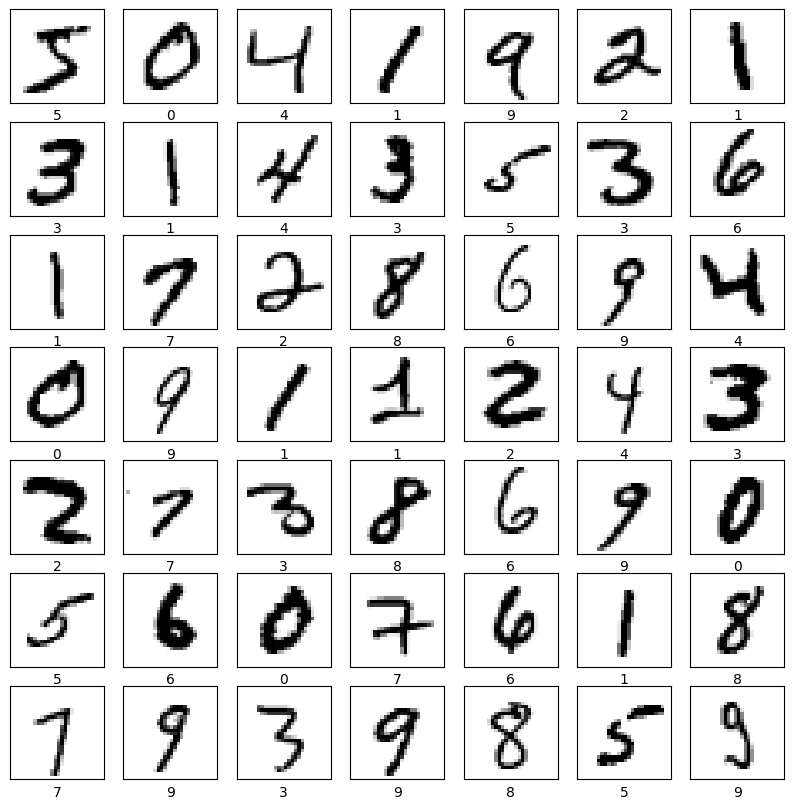

In [10]:
'''Observamos las imágenes para verificar en caso de algún error
o que no se muestren correctamente'''
plt.figure(figsize=(10,10))
for i in range(49):
  plt.subplot(7,7,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(train_data[i],cmap='gray_r')
  plt.xlabel(train_labels[i])
plt.show()

In [11]:
#Construimos las capas de la red neuronal
model=keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    #Aquí se le da una dimensión nueva a las imágenes a trabajar
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
#Selección y entrenamiento del modelo
model.fit(train_data, train_labels,epochs=6)

Epoch 1/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9231 - loss: 0.2653
Epoch 2/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9652 - loss: 0.1165
Epoch 3/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9763 - loss: 0.0789
Epoch 4/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9815 - loss: 0.0603
Epoch 5/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9862 - loss: 0.0456
Epoch 6/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9882 - loss: 0.0380


In [14]:
'''Al notar que la exactitud no aumenta significativamente
dejamos los epoch en 6 para evitar sobreajuste'''

'Al notar que la exactitud no aumenta significativamente\ndejamos los epoch en 6 para evitar sobreajuste'

In [15]:
#Evaluamos exactitud
test_loss,test_acc=model.evaluate(test_data,test_labels,verbose=2)
print("Exactitud de test:",test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.9766 - loss: 0.0773
Exactitud de test: 0.9765999913215637


In [16]:
#Prueba del modelo
predicciones=model.predict(test_data)
print("\nArreglo de predicciones")
print(predicciones[7])
print("\nPosición de nivel de confianza más alto del arreglo:")
print(np.argmax(predicciones[7]))
print("\nObservamos la etiqueta del test para corroborrar")
print(test_labels[7])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Arreglo de predicciones
[2.9310444e-08 1.6790082e-08 1.4736160e-05 9.8515023e-04 1.5383353e-04
 1.6119125e-06 7.0337514e-10 7.6232800e-06 1.2409953e-07 9.9883693e-01]

Posición de nivel de confianza más alto del arreglo:
9

Observamos la etiqueta del test para corroborrar
9


In [17]:
def plot_image(i, predicciones_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap='gray_r')
    predicted_label = np.argmax(predicciones_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'
    plt.xlabel(
        f"Predicción: {predicted_label} ({100*np.max(predicciones_array):2.0f}%)\nReal: {true_label}",
        color=color
    )
def plot_value_array(i, predicciones_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predicciones_array)
    plt.ylim([0,1])
    predicted_label = np.argmax(predicciones_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

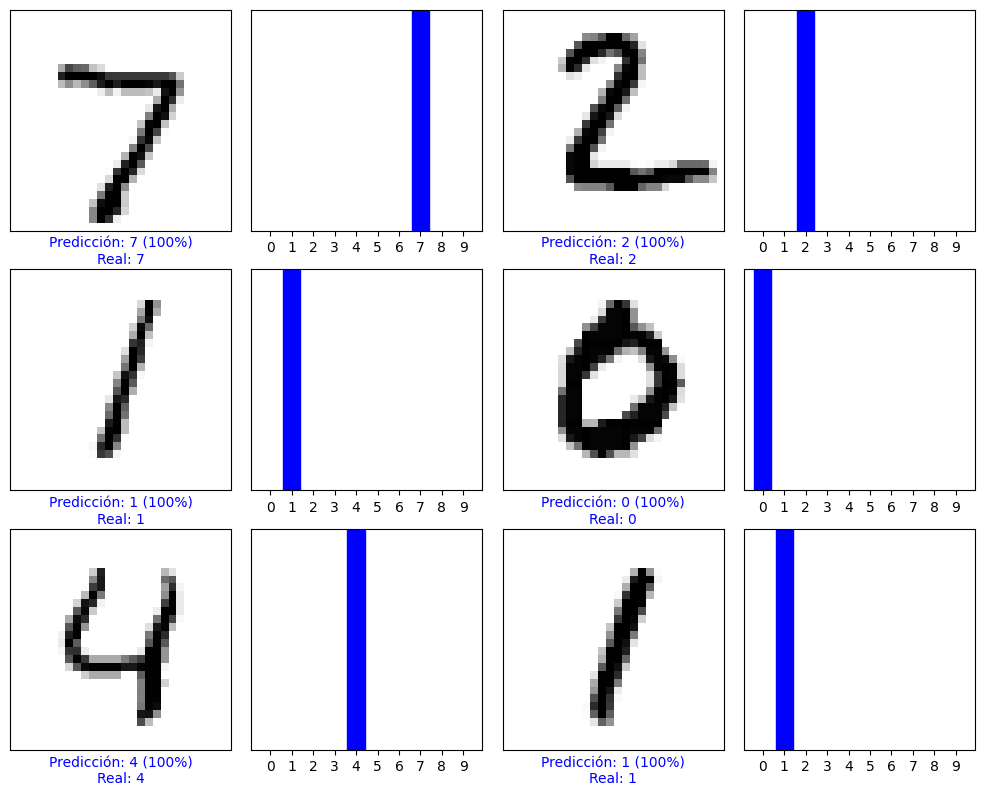

In [19]:
filas = 3
columnas = 2
imag=filas*columnas
plt.figure(figsize=(10,8))
for i in range(imag):
    plt.subplot(filas, 2*columnas, 2*i+1)
    plot_image(i, predicciones[i], test_labels, test_data)
    plt.subplot(filas, 2*columnas, 2*i+2)
    plot_value_array(i, predicciones[i], test_labels)
plt.tight_layout()
plt.show()